# Programming assignment 2: Random forests

Group: PA2 4

Members:
1.   Zheng Wei Liau (liau@chalmers.se)
2.   Jared Ng (jaredn@chalmers.se)


# Task 1: Working with a dataset with categorical features


In [ ]:
import pandas as pd

df_train = pd.read_csv('adult_train.csv')
df_test = pd.read_csv('adult_test.csv')

print(df_train.shape)
print(df_test.shape)

(32561, 14)
(16281, 14)


In the code below, we separate the input and output deatures of the train and test datasets.

In [ ]:
df_train_input = df_train.drop(columns=['target'])
df_train_target = df_train['target']

df_test_input = df_test.drop(columns=['target'])
df_test_target = df_test['target']

Then, we turn the train and test set input features into dictionaries and use the DictVectorizer to fit and transform the dictionaries.

In [ ]:
df_train_input_dict = df_train_input.to_dict('records')
df_test_input_dict = df_test_input.to_dict('records')

In [ ]:
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer()
X_train_encoded = dv.fit_transform(df_train_input_dict)

In [ ]:
X_test_encoded = dv.transform(df_test_input_dict)

Here, we use the Gradient Boosting Classifier to determine the cross validation score on the train set before determining the cross validation score for the test set.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

model = GradientBoostingClassifier()

train_scores = cross_val_score(model, X_train_encoded, df_train_target, cv=5)
print("Train scores for Gradient Boosting Classifier: ")
print(np.mean(train_scores))

Train scores for Gradient Boosting Classifier: 
0.8656368514152945


In [ ]:
test_scores = cross_val_score(model, X_test_encoded, df_test_target, cv=5)
print("Test scores for Gradient Boosting Classifier: ")
print(np.mean(test_scores))

Test scores for Gradient Boosting Classifier: 
0.8684359108599207


Here, we used a pipeline consisting of the DictVectorizer and the Gradient Boosting classifier to repeat the steps done above and obtain the test accuracy.

In [ ]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    DictVectorizer(),
    GradientBoostingClassifier()
    )

In [ ]:
pipeline.fit(df_train_input_dict, df_train_target)

Pipeline(steps=[('dictvectorizer', DictVectorizer()),
                ('gradientboostingclassifier', GradientBoostingClassifier())])

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = pipeline.predict(df_test_input_dict)
accuracy = accuracy_score(df_test_target, y_pred)
print("Test Accuracy:")
print(accuracy)

Test Accuracy:
0.8711381364781033


# Task 2: Decision trees and random forests


- In the code below, the Decision Tree Classifier is used with a range of depths from 1 to 20.
- The classifier is then fitted with the train data which has been previously encoded.
- This is then used to predict the target value of the train and the test. From this, we can determine the accuracy of the train and test sets at different depths.
- A graph is then plotted to show how the train and test set accuracy increases as the depth of the decision tree increases

Max Depth: 1, Train Accuracy: 0.7591904425539756, Test Accuracy: 0.7637737239727289
Max Depth: 2, Train Accuracy: 0.8282300912134148, Test Accuracy: 0.8306615072784227
Max Depth: 3, Train Accuracy: 0.8438930008292128, Test Accuracy: 0.8447884036607088
Max Depth: 4, Train Accuracy: 0.8438930008292128, Test Accuracy: 0.8447884036607088
Max Depth: 5, Train Accuracy: 0.8519701483369675, Test Accuracy: 0.8522818008721823
Max Depth: 6, Train Accuracy: 0.8570989834464543, Test Accuracy: 0.8575026104047663
Max Depth: 7, Train Accuracy: 0.8583888701206965, Test Accuracy: 0.8568883975185799
Max Depth: 8, Train Accuracy: 0.8605693928319155, Test Accuracy: 0.8568883975185799
Max Depth: 9, Train Accuracy: 0.8639476674549308, Test Accuracy: 0.8586696148885203
Max Depth: 10, Train Accuracy: 0.8694143300267191, Test Accuracy: 0.8610650451446471
Max Depth: 11, Train Accuracy: 0.873806087036639, Test Accuracy: 0.8602051471039862
Max Depth: 12, Train Accuracy: 0.8779214397592211, Test Accuracy: 0.8583625

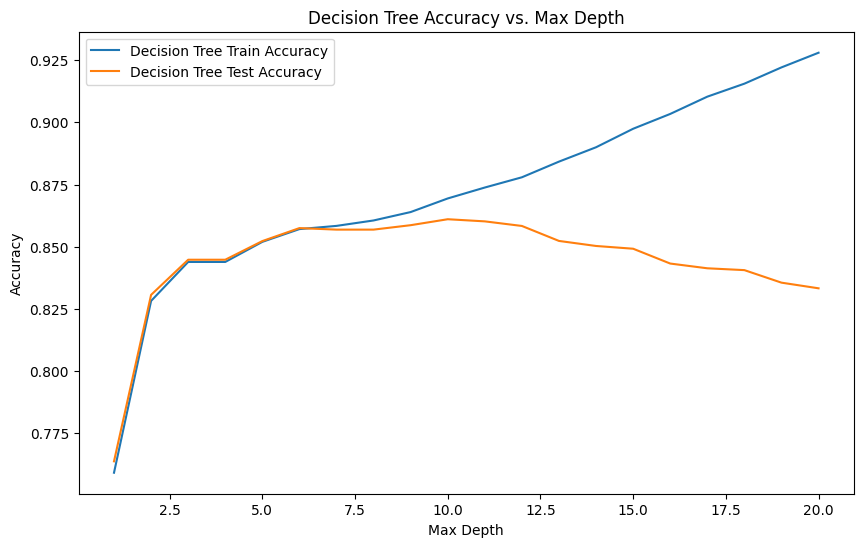

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_train_scores = []
dt_test_scores = []
depths = range(1, 21)

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_encoded, df_train_target)

    y_train_pred = model.predict(X_train_encoded)
    y_test_pred = model.predict(X_test_encoded)
    y_train_score = accuracy_score(df_train_target, y_train_pred)
    y_test_score = accuracy_score(df_test_target, y_test_pred)
    print(f"Max Depth: {depth}, Train Accuracy: {y_train_score}, Test Accuracy: {y_test_score}")

    dt_train_scores.append(y_train_score)
    dt_test_scores.append(y_test_score)

plt.figure(figsize=(10, 6))
plt.plot(depths, dt_train_scores, label='Decision Tree Train Accuracy')
plt.plot(depths, dt_test_scores, label='Decision Tree Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Max Depth')
plt.legend()
plt.show()

- From the graph, we can tell that there was underfitting at smaller tree depths with the test accuracy being higher than that of the train accuracy for most of the time
- At higher tree depths, we can see that there was overfitting as the train accuracy increases exponentially while the test accuracy decreases.
- From the graph we can tell that a tree depth of 6 is the most ideal.

- Now we replace the Decision Tree Classifier with the Random Forest Classifier and check for underfitting and overfitting based on the number of trees AKA n_estimators
- In this case, ensemble sizes of 1, 10, 50, 100 and 200 were chosen
- Using n_jobs=-1 to speed up the training time, we repeated the above experiment for Decision Tree classifier on the Random Forest classifier
- For each ensemble size, a curve of accuracy against tree depth is plotted for both the train and test set

Ensemble Size: 1, Max Depth: 1,     Train Accuracy: 0.8026166272534627, Test Accuracy: 0.8049259873472145
Ensemble Size: 1, Max Depth: 2,     Train Accuracy: 0.8026166272534627, Test Accuracy: 0.8049259873472145
Ensemble Size: 1, Max Depth: 3,     Train Accuracy: 0.8026166272534627, Test Accuracy: 0.8049259873472145
Ensemble Size: 1, Max Depth: 4,     Train Accuracy: 0.8190473265563097, Test Accuracy: 0.8193599901725939
Ensemble Size: 1, Max Depth: 5,     Train Accuracy: 0.8190166149688277, Test Accuracy: 0.8192371475953566
Ensemble Size: 1, Max Depth: 6,     Train Accuracy: 0.82171923466724, Test Accuracy: 0.8221239481604324
Ensemble Size: 1, Max Depth: 7,     Train Accuracy: 0.8299499401124044, Test Accuracy: 0.8296173453719059
Ensemble Size: 1, Max Depth: 8,     Train Accuracy: 0.8319154817112496, Test Accuracy: 0.8306615072784227
Ensemble Size: 1, Max Depth: 9,     Train Accuracy: 0.83600012284635, Test Accuracy: 0.8339168355752103
Ensemble Size: 1, Max Depth: 10,     Train Accurac

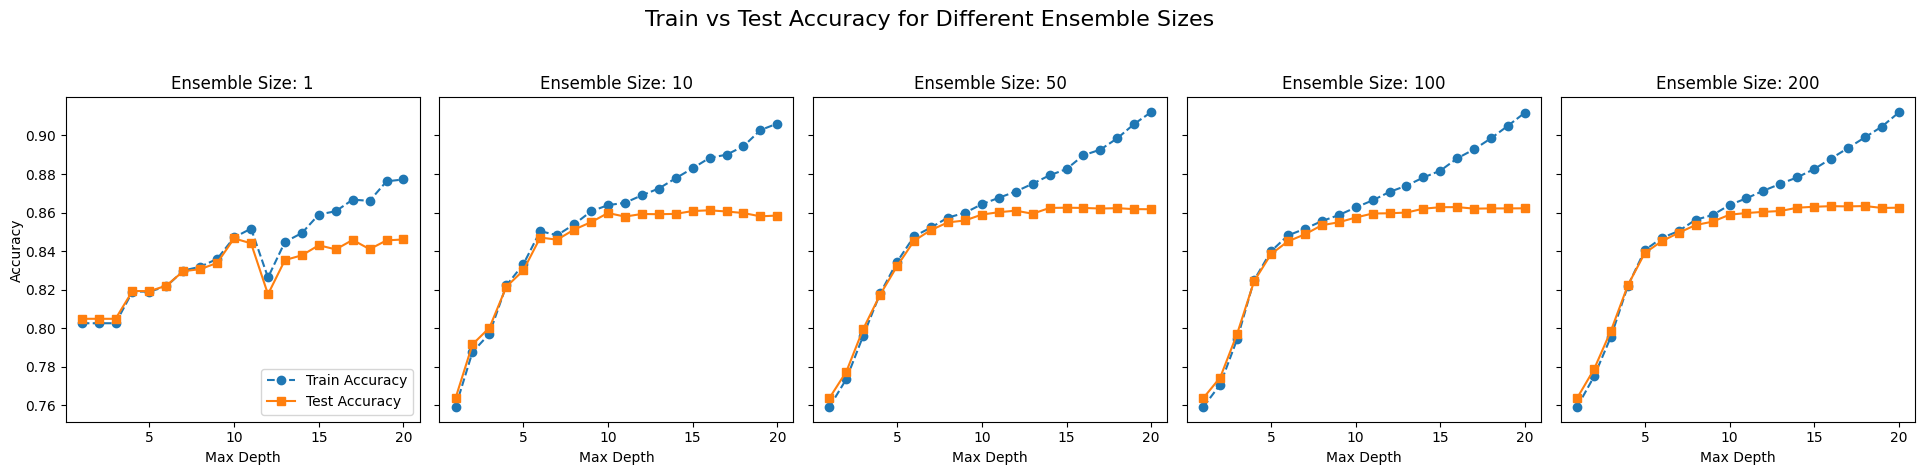

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

ensemble_sizes = [1,10,50,100,200]
depth_range = range(1,21)

# Dictionary to store results
train_results = {n: [] for n in ensemble_sizes}
test_results = {n: [] for n in ensemble_sizes}

importance_df_list = []

for n_estimators in ensemble_sizes:
  for max_depth in depth_range:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_encoded, df_train_target)

    y_train_pred = model.predict(X_train_encoded)
    y_test_pred = model.predict(X_test_encoded)

    y_train_score = accuracy_score(df_train_target, y_train_pred)
    y_test_score = accuracy_score(df_test_target, y_test_pred)
    print(f"Ensemble Size: {n_estimators}, Max Depth: {max_depth}, \
    Train Accuracy: {y_train_score}, Test Accuracy: {y_test_score}")

    train_results[n_estimators].append(y_train_score)
    test_results[n_estimators].append(y_test_score)

fig, axes = plt.subplots(1, len(ensemble_sizes), figsize=(20,5), sharey=True)

for idx, n_estimators in enumerate(ensemble_sizes):
    ax = axes[idx]

    axes[idx].plot(depth_range, train_results[n_estimators], label='Train Accuracy', linestyle='--', marker='o')
    axes[idx].plot(depth_range, test_results[n_estimators], label='Test Accuracy', linestyle='-', marker='s')

    axes[idx].set_title(f'Ensemble Size: {n_estimators}')
    axes[idx].set_xlabel('Max Depth')

fig.text(0.04, 0.5, 'Accuracy', va='center', rotation='vertical')

fig.suptitle('Train vs Test Accuracy for Different Ensemble Sizes', fontsize=16)
axes[0].legend(loc='lower right')

plt.tight_layout(rect=[0.04,0.04,1,0.95])
plt.show()

- The results are plotted in another way, showing the test accuracy over increasing tree depth for different ensemble sizes

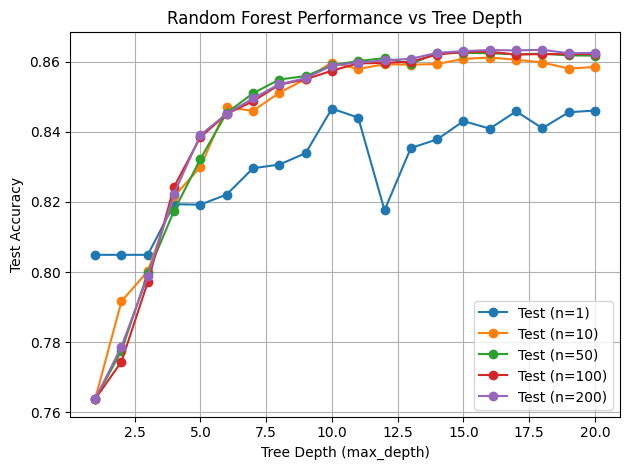

In [ ]:
for n_estimators in ensemble_sizes:
    plt.plot(depth_range, test_results[n_estimators],
             label=f'Test (n={n_estimators})', marker='o')

plt.xlabel("Tree Depth (max_depth)")
plt.ylabel("Test Accuracy")
plt.title("Random Forest Performance vs Tree Depth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now we will answer the following questions:
1. Difference between curve for a decision tree and for random forest with ensemble size 1 and why?
2. What happens to curve with random forests as the ensemble size grows
3. What happends with the best observed test set accuracy as esemble size grows
4. What happens with the training time as the ensemble size grows?

1. The curve for the decision tree increases at a decreasing rate and fluctuates less than that of the random forest classifier. In other words, the Decision Tree Classifier has lower bias and higher variance while the Random Forest Classifier has higher bias and lower variance.

  This is becuase the Decision Tree classifier considers all features, using the full dataset while the Random Forest Classifier considers a random subset of features, training on a bootstrapped sample.

2. As the ensemble size grows, the curve with random forest has becomes smoother with a steeper initial incline that turns into a plateau. Variance reduces along with overfitting

  Larger ensembles average out the noise and overfitting from individual trees

3. As the ensemble size grows, the best observed test set accuracy increases.

  With more trees, the model becomes more robust and less prone to overfitting individual samples

4. As the ensemble size grows, the training time increases too. The training time increases almost linearly with number of estimators.

# Task 3: Feature importances in random forest classifiers


We will be checking the computing the feature importances and sorting the importance scores using the default Decision Tree Classifier and Random Forest Classifier.

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_encoded, df_train_target)
feature_importances = model.feature_importances_
feature_name = dv.get_feature_names_out()

importance_df = pd.DataFrame({'Feature': feature_name, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

print(importance_df)

                               Feature  Importance
23   marital-status=Married-civ-spouse    0.214150
0                                  age    0.161722
3                        education-num    0.122841
1                         capital-gain    0.119142
20                      hours-per-week    0.098398
..                                 ...         ...
57                 native-country=Peru    0.000000
44             native-country=Honduras    0.000000
79          occupation=Priv-house-serv    0.000000
101             workclass=Never-worked    0.000000
106              workclass=Without-pay    0.000000

[107 rows x 2 columns]


We can see that the important features for the Decision Tree Classifier are:

1. marital-status=Married-civ-spouse
2. age
3. education-num
4. capital-gain
5. hours-per-week




In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_encoded, df_train_target)
feature_importances = model.feature_importances_
feature_name = dv.get_feature_names_out()

importance_df = pd.DataFrame({'Feature': feature_name, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

print(importance_df)

                                       Feature  Importance
0                                          age    0.225806
20                              hours-per-week    0.115292
1                                 capital-gain    0.110695
3                                education-num    0.061295
23           marital-status=Married-civ-spouse    0.059411
..                                         ...         ...
56   native-country=Outlying-US(Guam-USVI-etc)    0.000023
72                     occupation=Armed-Forces    0.000013
44                     native-country=Honduras    0.000005
43           native-country=Holand-Netherlands    0.000004
101                     workclass=Never-worked    0.000004

[107 rows x 2 columns]


We can see that the important features for the Random Forest Classifier are:

1. age
2. hours-per-week
3. capital-gain
4. education-num
5. marital-status=Married-civ-spouse

We can see that both the Decision Tree and Random Forest Classifiers have the same important features in their top 5 list, but in a different order.

### Alternative Way to Compute
An alternative way to compute the importance score of the feature is to use permutation importance, as it would shuffle each predictor variable. By shuffling the values of the feature, we can tell which features are important.